# Hipotesis 1: Posesion vs goles y resultado

Paso a paso: cargamos datos, calculamos posesion por equipo/partido,
y comparamos con goles y resultado.

In [9]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [10]:
BASE_DIR = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed')
events_path = BASE_DIR / 'events' / 'events_fact.parquet'
matches_path = BASE_DIR / 'matches' / 'matches_fact.parquet'
events = pd.read_parquet(events_path)
matches = pd.read_parquet(matches_path)
events.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_11684\660835750.py:1: SyntaxWarning: invalid escape sequence '\C'
  BASE_DIR = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed')


,event_id,match_id,index,period,timestamp,minute,second,event_type_id,event_type_name,team_id,...,possession_team_id,play_pattern_id,play_pattern_name,duration,under_pressure,related_events,x,y,end_x,end_y
0,0b483cd2-1d36-49a0-85c2-149a9de553df,7298,1,1,00:00:00.000,0,0,35,Starting XI,746,...,746,1,Regular Play,0.00,None,NaN,NaN,NaN,NaN,NaN
1,2c873afb-73bb-48a1-9fd5-bfe1400b4a83,7298,2,1,00:00:00.000,0,0,35,Starting XI,971,...,746,1,Regular Play,0.00,None,NaN,NaN,NaN,NaN,NaN
2,040940a1-5972-431e-b6ac-e723edd8e7c2,7298,3,1,00:00:00.000,0,0,18,Half Start,746,...,746,1,Regular Play,7.96,None,"[""5ba286bd-c397-4ac4-b12f-6bace943afce""]",NaN,NaN,NaN,NaN
3,5ba286bd-c397-4ac4-b12f-6bace943afce,7298,4,1,00:00:00.000,0,0,18,Half Start,971,...,746,1,Regular Play,8.16,None,"[""040940a1-5972-431e-b6ac-e723edd8e7c2""]",NaN,NaN,NaN,NaN
4,2a456ec2-352c-499b-b5cc-e68bf84c7e9a,7298,5,1,00:00:00.100,0,0,30,Pass,971,...,971,9,From Kick Off,0.00,None,"[""483b7286-e75e-4191-80be-ac93bfed1473""]",61.0,40.0,63.0,37.0


In [11]:
# Paso 1: posesion por equipo y partido
pos_counts = (events
    .dropna(subset=['possession_team_id', 'match_id'])
    .groupby(['match_id', 'possession_team_id'])
    .size()
    .reset_index(name='eventos_possesion')
)
totals = (pos_counts
    .groupby('match_id')['eventos_possesion']
    .sum()
    .reset_index(name='eventos_total')
)
pos_df = pos_counts.merge(totals, on='match_id')
pos_df['posesion_pct'] = pos_df['eventos_possesion'] / pos_df['eventos_total']
pos_df.head()

,match_id,possession_team_id,eventos_possesion,eventos_total,posesion_pct
0,7298,746,1861,3793,0.490641
1,7298,971,1932,3793,0.509359
2,7430,759,1741,3529,0.493341
3,7430,766,1788,3529,0.506659
4,7443,760,1318,3036,0.434124


In [12]:
# Paso 2: preparar tabla de resultados por equipo
home = matches[['match_id', 'home_team_id', 'home_score', 'away_score']].copy()
home['team_id'] = home['home_team_id']
home['goles_favor'] = home['home_score']
home['goles_contra'] = home['away_score']
home['condicion'] = 'home'
away = matches[['match_id', 'away_team_id', 'home_score', 'away_score']].copy()
away['team_id'] = away['away_team_id']
away['goles_favor'] = away['away_score']
away['goles_contra'] = away['home_score']
away['condicion'] = 'away'
results = pd.concat([home, away], ignore_index=True)
results['resultado'] = results['goles_favor'].sub(results['goles_contra'])
results.head()

,match_id,home_team_id,home_score,away_score,team_id,goles_favor,goles_contra,condicion,away_team_id,resultado
0,3895302,904.0,5,0,904,5,0,home,NaN,5
1,3895292,190.0,0,1,190,0,1,home,NaN,-1
2,3895333,184.0,1,5,184,1,5,home,NaN,-4
3,3895340,868.0,0,5,868,0,5,home,NaN,-5
4,3895348,904.0,2,1,904,2,1,home,NaN,1


In [13]:
# Paso 3: unir posesion con resultados
df = pos_df.merge(results, left_on=['match_id', 'possession_team_id'], right_on=['match_id', 'team_id'])
df[['match_id', 'team_id', 'posesion_pct', 'goles_favor', 'goles_contra', 'resultado']].head()

,match_id,team_id,posesion_pct,goles_favor,goles_contra,resultado
0,7298,746,0.490641,2,2,0
1,7298,971,0.509359,2,2,0
2,7430,759,0.493341,2,4,-2
3,7430,766,0.506659,4,2,2
4,7443,760,0.434124,3,2,1


In [14]:
# Paso 4: exploracion rapida
df['resultado_cat'] = pd.cut(df['resultado'], bins=[-10, -1, 0, 10], labels=['derrota', 'empate', 'victoria'])
df.groupby('resultado_cat')['posesion_pct'].describe()

,count,mean,std,min,25%,50%,75%,max
resultado_cat,,,,,,,,
derrota,2664.0,0.459279,0.122103,0.147112,0.367332,0.457292,0.544948,0.832135
empate,1594.0,0.500000,0.124452,0.147675,0.411149,0.500000,0.588851,0.852325
victoria,2665.0,0.540793,0.122138,0.167865,0.455059,0.542720,0.632800,0.852888


C:\Users\Usuario\AppData\Local\Temp\ipykernel_11684\725005316.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="resultado_cat", y="posesion_pct", palette="Set2")


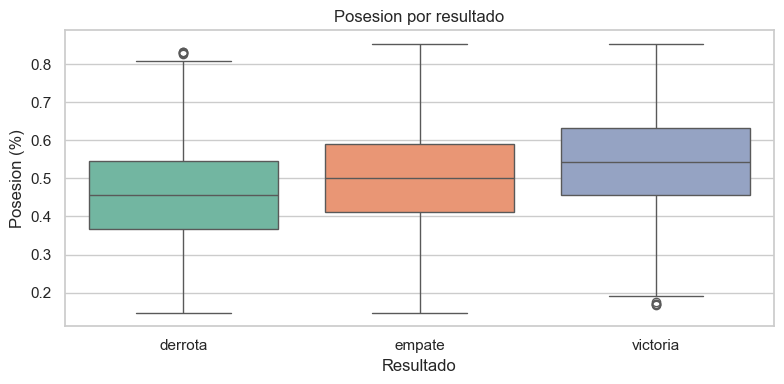

In [15]:
# Paso 4b: boxplot de posesion por resultado
from pathlib import Path

fig_dir = Path("docs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="resultado_cat", y="posesion_pct", palette="Set2")
plt.title("Posesion por resultado")
plt.xlabel("Resultado")
plt.ylabel("Posesion (%)")
plt.tight_layout()
plt.savefig(fig_dir / "h1_posesion_boxplot.png", dpi=160)
plt.show()

In [16]:
# Paso 5: correlaciones simples
df[['posesion_pct', 'goles_favor', 'goles_contra', 'resultado']].corr()

,posesion_pct,goles_favor,goles_contra,resultado
posesion_pct,1.000000,0.291450,-0.291450,0.378609
goles_favor,0.291450,1.000000,-0.185158,0.769791
goles_contra,-0.291450,-0.185158,1.000000,-0.769791
resultado,0.378609,0.769791,-0.769791,1.000000


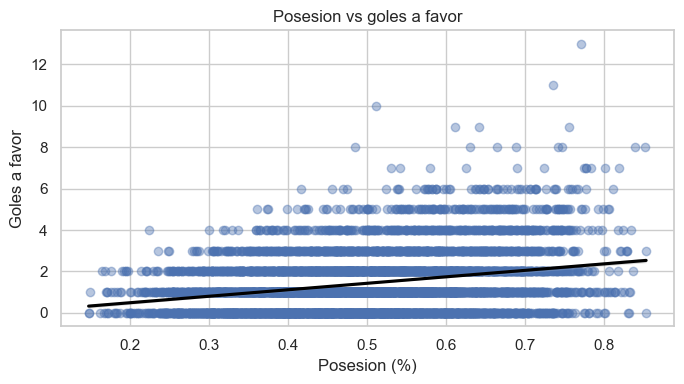

In [17]:
# Paso 5b: relacion posesion vs goles a favor
plt.figure(figsize=(7, 4))
sns.regplot(data=df, x="posesion_pct", y="goles_favor", scatter_kws={"alpha": 0.4}, line_kws={"color": "black"})
plt.title("Posesion vs goles a favor")
plt.xlabel("Posesion (%)")
plt.ylabel("Goles a favor")
plt.tight_layout()
plt.savefig(fig_dir / "h1_posesion_scatter.png", dpi=160)
plt.show()